In [ ]:
import matplotlib as plt
import pandas as pd
import numpy as np

saved power_lollipop.png


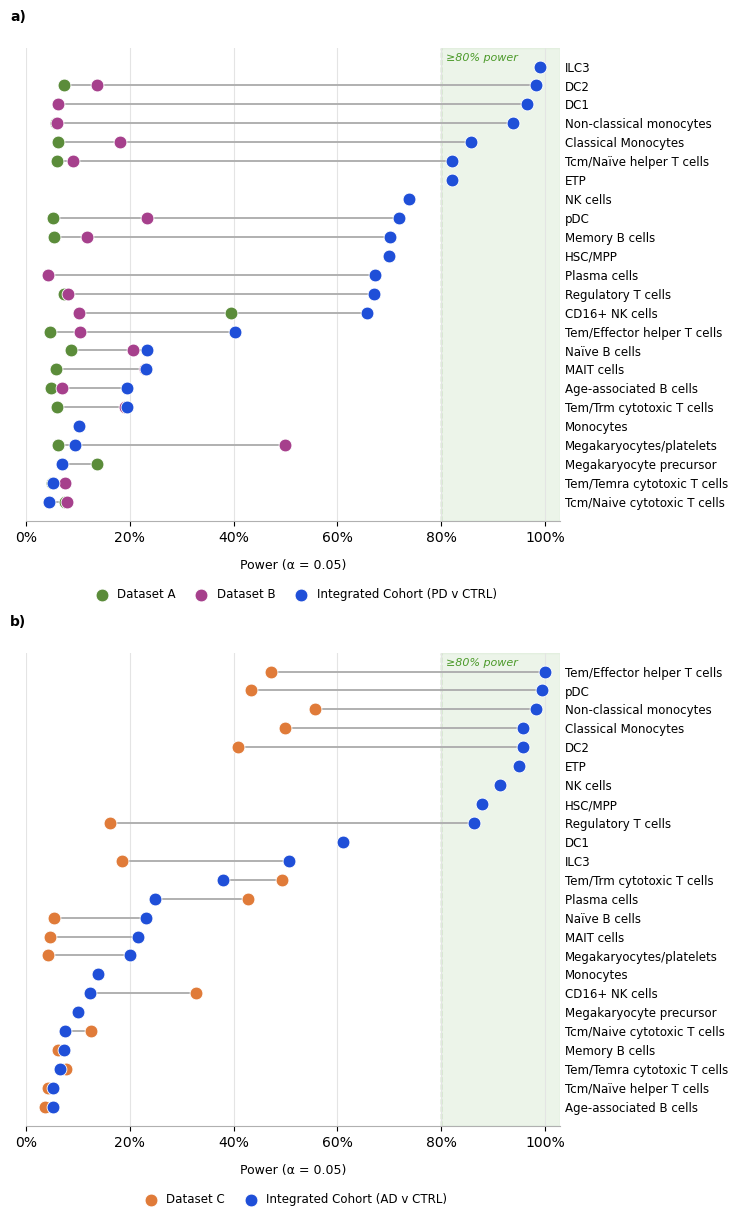

In [6]:
"""
make_power_lollipop.py

Two-panel dumbbell/lollipop plot comparing per-cell-type statistical power
(alpha = 0.05) for individual datasets vs. the integrated cohort:
  a) PD vs CTRL   (Dataset A, Dataset B, Integrated Cohort)
  b) AD vs CTRL   (Dataset C, Integrated Cohort)

Data is hardcoded below as two pandas DataFrames (index = cell type,
columns = series name). Edit PD_DATA / AD_DATA directly to update numbers
-- no external file needed.

The region from POWER_THRESHOLD (default 0.8) onward is shaded to flag
adequately powered comparisons.
"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# Data — edit these directly to update the plot
# ---------------------------------------------------------------------------

PD_DATA = pd.DataFrame(
    {
        "Dataset A": {
            "Classical Monocytes": 0.062, "Tcm/Naïve helper T cells": 0.06,
            "Tem/Trm cytotoxic T cells": 0.06, "CD16+ NK cells": 0.395,
            "Age-associated B cells": 0.048, "DC2": 0.073, "MAIT cells": 0.057,
            "Tem/Effector helper T cells": 0.047, "Tem/Temra cytotoxic T cells": 0.051,
            "pDC": 0.052, "Megakaryocyte precursor": 0.136, "Megakaryocytes/platelets": 0.062,
            "Memory B cells": 0.054, "Naïve B cells": 0.087, "Non-classical monocytes": 0.058,
            "Regulatory T cells": 0.073, "Tcm/Naive cytotoxic T cells": 0.075,
            "DC1": np.nan, "Plasma cells": np.nan, "ILC3": np.nan, "ETP": np.nan,
            "HSC/MPP": np.nan, "Monocytes": np.nan, "NK cells": np.nan,
        },
        "Dataset B": {
            "Classical Monocytes": 0.182, "Tcm/Naïve helper T cells": 0.091,
            "Tem/Trm cytotoxic T cells": 0.191, "CD16+ NK cells": 0.103,
            "Age-associated B cells": 0.069, "DC2": 0.137, "MAIT cells": 0.229,
            "Tem/Effector helper T cells": 0.104, "Tem/Temra cytotoxic T cells": 0.076,
            "pDC": 0.234, "Megakaryocyte precursor": np.nan, "Megakaryocytes/platelets": 0.5,
            "Memory B cells": 0.117, "Naïve B cells": 0.207, "Non-classical monocytes": 0.059,
            "Regulatory T cells": 0.081, "Tcm/Naive cytotoxic T cells": 0.079,
            "DC1": 0.061, "Plasma cells": 0.042, "ILC3": np.nan, "ETP": np.nan,
            "HSC/MPP": np.nan, "Monocytes": np.nan, "NK cells": np.nan,
        },
        "Integrated Cohort (PD v CTRL)": {
            "Classical Monocytes": 0.858, "Tcm/Naïve helper T cells": 0.82,
            "Tem/Trm cytotoxic T cells": 0.194, "CD16+ NK cells": 0.658,
            "Age-associated B cells": 0.195, "DC2": 0.982, "MAIT cells": 0.231,
            "Tem/Effector helper T cells": 0.403, "Tem/Temra cytotoxic T cells": 0.052,
            "pDC": 0.719, "Megakaryocyte precursor": 0.069, "Megakaryocytes/platelets": 0.094,
            "Memory B cells": 0.701, "Naïve B cells": 0.233, "Non-classical monocytes": 0.939,
            "Regulatory T cells": 0.67, "Tcm/Naive cytotoxic T cells": 0.045,
            "DC1": 0.966, "Plasma cells": 0.672, "ILC3": 0.99, "ETP": 0.82,
            "HSC/MPP": 0.7, "Monocytes": 0.102, "NK cells": 0.738,
        },
    }
)

AD_DATA = pd.DataFrame(
    {
        "Dataset C": {
            "Classical Monocytes": 0.5, "Tcm/Naïve helper T cells": 0.043,
            "Tem/Trm cytotoxic T cells": 0.494, "CD16+ NK cells": 0.328,
            "Age-associated B cells": 0.036, "DC2": 0.408, "MAIT cells": 0.046,
            "Tem/Effector helper T cells": 0.472, "Tem/Temra cytotoxic T cells": 0.077,
            "pDC": 0.434, "Megakaryocyte precursor": np.nan, "Megakaryocytes/platelets": 0.042,
            "Memory B cells": 0.062, "Naïve B cells": 0.053, "Non-classical monocytes": 0.557,
            "Regulatory T cells": 0.162, "Tcm/Naive cytotoxic T cells": 0.125,
            "DC1": np.nan, "Plasma cells": 0.427, "ILC3": 0.185, "ETP": np.nan,
            "HSC/MPP": np.nan, "Monocytes": np.nan, "NK cells": np.nan,
        },
        "Integrated Cohort (AD v CTRL)": {
            "Classical Monocytes": 0.957, "Tcm/Naïve helper T cells": 0.052,
            "Tem/Trm cytotoxic T cells": 0.38, "CD16+ NK cells": 0.124,
            "Age-associated B cells": 0.052, "DC2": 0.957, "MAIT cells": 0.215,
            "Tem/Effector helper T cells": 1.0, "Tem/Temra cytotoxic T cells": 0.065,
            "pDC": 0.994, "Megakaryocyte precursor": 0.1, "Megakaryocytes/platelets": 0.2,
            "Memory B cells": 0.073, "Naïve B cells": 0.232, "Non-classical monocytes": 0.983,
            "Regulatory T cells": 0.864, "Tcm/Naive cytotoxic T cells": 0.075,
            "DC1": 0.61, "Plasma cells": 0.248, "ILC3": 0.507, "ETP": 0.951,
            "HSC/MPP": 0.878, "Monocytes": 0.138, "NK cells": 0.914,
        },
    }
)

# ---------------------------------------------------------------------------
# Styling
# ---------------------------------------------------------------------------

SERIES_COLORS = {
    "Dataset A": "#5B8C3A",  # green
    "Dataset B": "#A6408C",  # magenta
    "Dataset C": "#E07B39",  # orange
}
INTEGRATED_COLOR = "#1f4fd8"  # blue
POWER_THRESHOLD = 0.8
SHADE_COLOR = "#4C9A2A"


def plot_panel(ax, df, panel_label, sort_col=None):
    df = df.copy()
    sort_col = sort_col or df.columns[-1]
    df = df.loc[df[sort_col].sort_values(ascending=False, na_position="last").index]

    celltypes = list(df.index)
    series_names = list(df.columns)
    values = df.values  # (n_celltypes, n_series)

    n = len(celltypes)
    y = np.arange(n)[::-1]  # highest integrated-cohort power at the top

    ax.set_xlim(0, 1.03)

    # shade the "adequately powered" region
    ax.axvspan(POWER_THRESHOLD, ax.get_xlim()[1], color=SHADE_COLOR, alpha=0.10, zorder=0)
    ax.axvline(POWER_THRESHOLD, color=SHADE_COLOR, linewidth=1, linestyle="--", alpha=0.5, zorder=0.5)
    ax.text(
        POWER_THRESHOLD + 0.01, n - 0.3, f"≥{int(POWER_THRESHOLD * 100)}% power",
        color=SHADE_COLOR, fontsize=8, style="italic", va="top",
    )

    # connecting line spanning the available values in each row
    for yi, row in zip(y, values):
        finite = row[~np.isnan(row)]
        if len(finite) > 1:
            ax.hlines(yi, finite.min(), finite.max(), color="#B0B0B0", linewidth=1.4, zorder=1)

    for j, name in enumerate(series_names):
        color = INTEGRATED_COLOR if "Integrated" in name else SERIES_COLORS.get(name, "#888888")
        vals = values[:, j]
        mask = ~np.isnan(vals)
        ax.scatter(
            vals[mask], y[mask], color=color, s=85, zorder=2,
            label=name, edgecolor="white", linewidth=0.6,
        )

    ax.set_yticks(y)
    ax.set_yticklabels(celltypes, fontsize=8.5)
    ax.yaxis.tick_right()
    ax.tick_params(axis="y", length=0)
    ax.set_ylim(-1, n)

    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v * 100:.0f}%"))
    ax.set_xlabel("Power (α = 0.05)", fontsize=9, labelpad=10)

    ax.grid(axis="x", color="#E4E4E4", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "left", "right"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color("#B0B0B0")

    ax.text(-0.03, 1.05, panel_label, transform=ax.transAxes,
            fontsize=10, fontweight="bold", va="bottom")
    ax.legend(
        loc="upper center", bbox_to_anchor=(0.5, -0.12),
        frameon=False, fontsize=8.5, ncol=len(series_names),
        handletextpad=0.3, columnspacing=1.2,
    )


def main(out_path="power_lollipop.png"):
    plt.rcParams["font.family"] = "DejaVu Sans"
    fig, axes = plt.subplots(2, 1, figsize=(7.5, 12.5))

    plot_panel(axes[0], PD_DATA, "a)", sort_col="Integrated Cohort (PD v CTRL)")
    plot_panel(axes[1], AD_DATA, "b)", sort_col="Integrated Cohort (AD v CTRL)")

    # fig.suptitle(
    #     "Statistical power by cell type: individual datasets vs. integrated cohort",
    #     fontsize=12.5, y=0.995,
    # )
    fig.tight_layout(rect=(0, 0, 1, 0.98))
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    print(f"saved {out_path}")


if __name__ == "__main__":
    main()

saved power_lollipop.svg


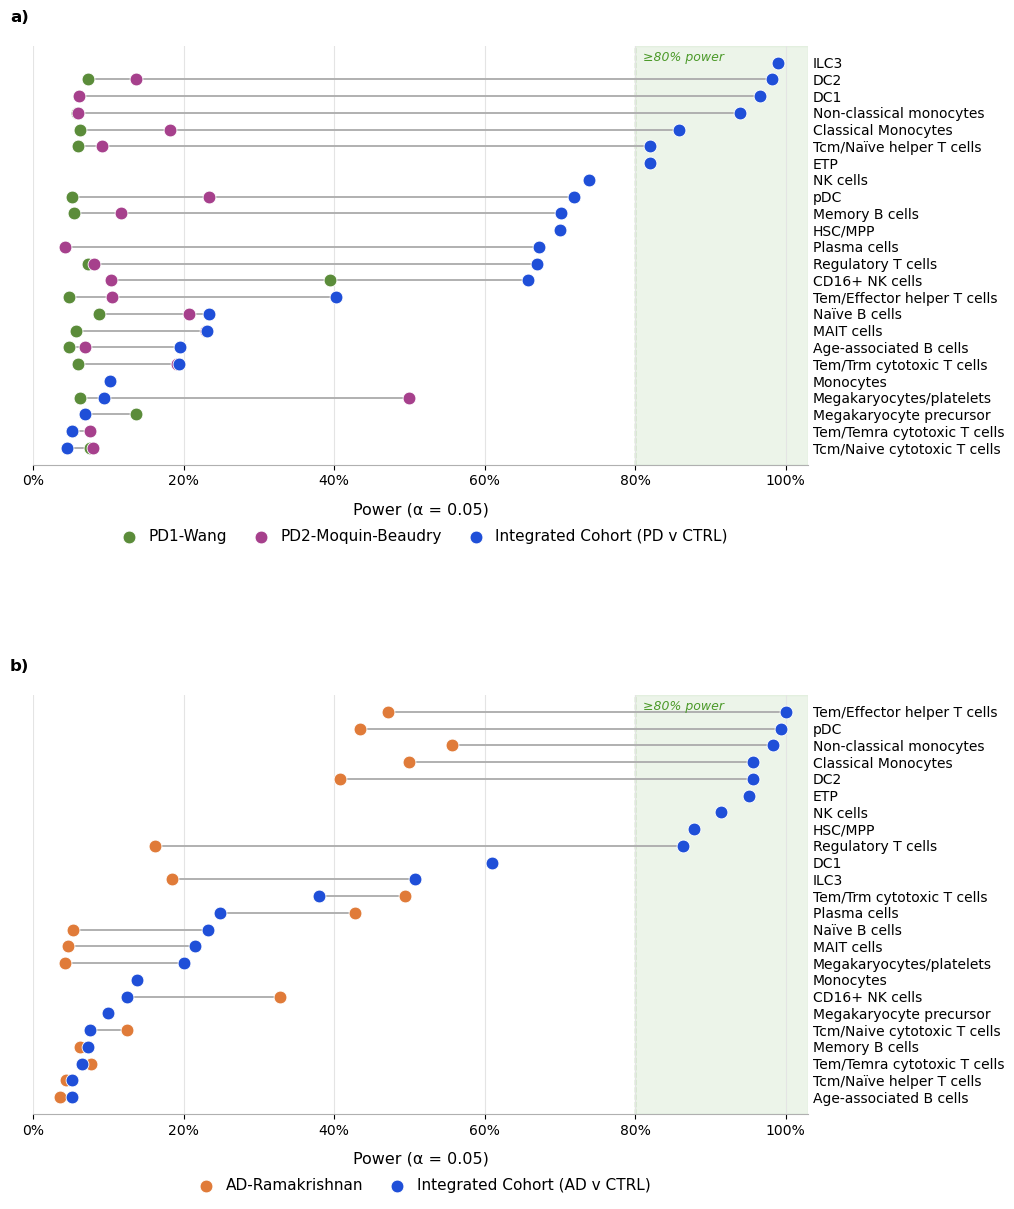

In [24]:
"""
make_power_lollipop.py

Two-panel dumbbell/lollipop plot comparing per-cell-type statistical power
(alpha = 0.05) for individual datasets vs. the integrated cohort:
  a) PD vs CTRL   (Dataset A, Dataset B, Integrated Cohort)
  b) AD vs CTRL   (Dataset C, Integrated Cohort)

Data is hardcoded below as two pandas DataFrames (index = cell type,
columns = series name). Edit PD_DATA / AD_DATA directly to update numbers
-- no external file needed.

The region from POWER_THRESHOLD (default 0.8) onward is shaded to flag
adequately powered comparisons.
"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# Data — edit these directly to update the plot
# ---------------------------------------------------------------------------

PD_DATA = pd.DataFrame(
    {
        "PD1-Wang": {
            "Classical Monocytes": 0.062, "Tcm/Naïve helper T cells": 0.06,
            "Tem/Trm cytotoxic T cells": 0.06, "CD16+ NK cells": 0.395,
            "Age-associated B cells": 0.048, "DC2": 0.073, "MAIT cells": 0.057,
            "Tem/Effector helper T cells": 0.047, "Tem/Temra cytotoxic T cells": 0.051,
            "pDC": 0.052, "Megakaryocyte precursor": 0.136, "Megakaryocytes/platelets": 0.062,
            "Memory B cells": 0.054, "Naïve B cells": 0.087, "Non-classical monocytes": 0.058,
            "Regulatory T cells": 0.073, "Tcm/Naive cytotoxic T cells": 0.075,
            "DC1": np.nan, "Plasma cells": np.nan, "ILC3": np.nan, "ETP": np.nan,
            "HSC/MPP": np.nan, "Monocytes": np.nan, "NK cells": np.nan,
        },
        "PD2-Moquin-Beaudry": {
            "Classical Monocytes": 0.182, "Tcm/Naïve helper T cells": 0.091,
            "Tem/Trm cytotoxic T cells": 0.191, "CD16+ NK cells": 0.103,
            "Age-associated B cells": 0.069, "DC2": 0.137, "MAIT cells": 0.229,
            "Tem/Effector helper T cells": 0.104, "Tem/Temra cytotoxic T cells": 0.076,
            "pDC": 0.234, "Megakaryocyte precursor": np.nan, "Megakaryocytes/platelets": 0.5,
            "Memory B cells": 0.117, "Naïve B cells": 0.207, "Non-classical monocytes": 0.059,
            "Regulatory T cells": 0.081, "Tcm/Naive cytotoxic T cells": 0.079,
            "DC1": 0.061, "Plasma cells": 0.042, "ILC3": np.nan, "ETP": np.nan,
            "HSC/MPP": np.nan, "Monocytes": np.nan, "NK cells": np.nan,
        },
        "Integrated Cohort (PD v CTRL)": {
            "Classical Monocytes": 0.858, "Tcm/Naïve helper T cells": 0.82,
            "Tem/Trm cytotoxic T cells": 0.194, "CD16+ NK cells": 0.658,
            "Age-associated B cells": 0.195, "DC2": 0.982, "MAIT cells": 0.231,
            "Tem/Effector helper T cells": 0.403, "Tem/Temra cytotoxic T cells": 0.052,
            "pDC": 0.719, "Megakaryocyte precursor": 0.069, "Megakaryocytes/platelets": 0.094,
            "Memory B cells": 0.701, "Naïve B cells": 0.233, "Non-classical monocytes": 0.939,
            "Regulatory T cells": 0.67, "Tcm/Naive cytotoxic T cells": 0.045,
            "DC1": 0.966, "Plasma cells": 0.672, "ILC3": 0.99, "ETP": 0.82,
            "HSC/MPP": 0.7, "Monocytes": 0.102, "NK cells": 0.738,
        },
    }
)

AD_DATA = pd.DataFrame(
    {
        "AD-Ramakrishnan": {
            "Classical Monocytes": 0.5, "Tcm/Naïve helper T cells": 0.043,
            "Tem/Trm cytotoxic T cells": 0.494, "CD16+ NK cells": 0.328,
            "Age-associated B cells": 0.036, "DC2": 0.408, "MAIT cells": 0.046,
            "Tem/Effector helper T cells": 0.472, "Tem/Temra cytotoxic T cells": 0.077,
            "pDC": 0.434, "Megakaryocyte precursor": np.nan, "Megakaryocytes/platelets": 0.042,
            "Memory B cells": 0.062, "Naïve B cells": 0.053, "Non-classical monocytes": 0.557,
            "Regulatory T cells": 0.162, "Tcm/Naive cytotoxic T cells": 0.125,
            "DC1": np.nan, "Plasma cells": 0.427, "ILC3": 0.185, "ETP": np.nan,
            "HSC/MPP": np.nan, "Monocytes": np.nan, "NK cells": np.nan,
        },
        "Integrated Cohort (AD v CTRL)": {
            "Classical Monocytes": 0.957, "Tcm/Naïve helper T cells": 0.052,
            "Tem/Trm cytotoxic T cells": 0.38, "CD16+ NK cells": 0.124,
            "Age-associated B cells": 0.052, "DC2": 0.957, "MAIT cells": 0.215,
            "Tem/Effector helper T cells": 1.0, "Tem/Temra cytotoxic T cells": 0.065,
            "pDC": 0.994, "Megakaryocyte precursor": 0.1, "Megakaryocytes/platelets": 0.2,
            "Memory B cells": 0.073, "Naïve B cells": 0.232, "Non-classical monocytes": 0.983,
            "Regulatory T cells": 0.864, "Tcm/Naive cytotoxic T cells": 0.075,
            "DC1": 0.61, "Plasma cells": 0.248, "ILC3": 0.507, "ETP": 0.951,
            "HSC/MPP": 0.878, "Monocytes": 0.138, "NK cells": 0.914,
        },
    }
)

# ---------------------------------------------------------------------------
# Styling
# ---------------------------------------------------------------------------

SERIES_COLORS = {
    "PD1-Wang": "#5B8C3A",  # green
    "PD2-Moquin-Beaudry": "#A6408C",  # magenta
    "AD-Ramakrishnan": "#E07B39",  # orange
}
INTEGRATED_COLOR = "#1f4fd8"  # blue
POWER_THRESHOLD = 0.8
SHADE_COLOR = "#4C9A2A"


def plot_panel(ax, df, panel_label, sort_col=None):
    df = df.copy()
    sort_col = sort_col or df.columns[-1]
    df = df.loc[df[sort_col].sort_values(ascending=False, na_position="last").index]

    celltypes = list(df.index)
    series_names = list(df.columns)
    values = df.values  # (n_celltypes, n_series)

    n = len(celltypes)
    y = np.arange(n)[::-1]  # highest integrated-cohort power at the top

    ax.set_xlim(0, 1.03)

    # shade the "adequately powered" region
    ax.axvspan(POWER_THRESHOLD, ax.get_xlim()[1], color=SHADE_COLOR, alpha=0.10, zorder=0)
    ax.axvline(POWER_THRESHOLD, color=SHADE_COLOR, linewidth=1, linestyle="--", alpha=0.5, zorder=0.5)
    ax.text(
        POWER_THRESHOLD + 0.01, n - 0.3, f"≥{int(POWER_THRESHOLD * 100)}% power",
        color=SHADE_COLOR, fontsize=9, style="italic", va="top",
    )

    # connecting line spanning the available values in each row
    for yi, row in zip(y, values):
        finite = row[~np.isnan(row)]
        if len(finite) > 1:
            ax.hlines(yi, finite.min(), finite.max(), color="#B0B0B0", linewidth=1.4, zorder=1)

    for j, name in enumerate(series_names):
        color = INTEGRATED_COLOR if "Integrated" in name else SERIES_COLORS.get(name, "#888888")
        vals = values[:, j]
        mask = ~np.isnan(vals)
        ax.scatter(
            vals[mask], y[mask], color=color, s=85, zorder=2,
            label=name, edgecolor="white", linewidth=0.6,
        )

    ax.set_yticks(y)
    ax.set_yticklabels(celltypes, fontsize=10)
    ax.yaxis.tick_right()
    ax.tick_params(axis="y", length=0)
    ax.set_ylim(-1, n)

    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v * 100:.0f}%"))
    ax.set_xlabel("Power (α = 0.05)", fontsize=11.5, labelpad=10)

    ax.grid(axis="x", color="#E4E4E4", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "left", "right"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color("#B0B0B0")

    ax.text(-0.03, 1.05, panel_label, transform=ax.transAxes,
            fontsize=12, fontweight="bold", va="bottom")
    ax.legend(
        loc="upper center", bbox_to_anchor=(0.5, -0.12),
        frameon=False, fontsize=11, ncol=len(series_names),
        handletextpad=0.3, columnspacing=1.2,
    )


def main(out_path="power_lollipop.svg"):
    plt.rcParams["font.family"] = "DejaVu Sans"
    fig, axes = plt.subplots(2, 1, figsize=(10, 12))

    plot_panel(axes[0], PD_DATA, "a)", sort_col="Integrated Cohort (PD v CTRL)")
    plot_panel(axes[1], AD_DATA, "b)", sort_col="Integrated Cohort (AD v CTRL)")

    # fig.suptitle(
    #     "Statistical power by cell type: individual datasets vs. integrated cohort",
    #     fontsize=12.5, y=0.995,
    # )
    fig.subplots_adjust(top=0.94, bottom=0.05, hspace=0.55)
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    print(f"saved {out_path}")


if __name__ == "__main__":
    main()